In [16]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
df = pd.read_excel("Bajaj_Finance_Loan_Dataset Sample.xlsx")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nPD Distribution:")
print(df["PD"].value_counts())
print(f"\nDefault Rate: {df['PD'].mean():.2%}")
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Rows: 1000, Columns: 49

PD Distribution:
PD
0    539
1    461
Name: count, dtype: int64

Default Rate: 46.10%

Missing Values:
Product 2       571
Product 3       908
Unnamed: 43    1000
Unnamed: 44    1000
Unnamed: 45    1000
Unnamed: 46    1000
Unnamed: 47     986
Unnamed: 48     986
dtype: int64


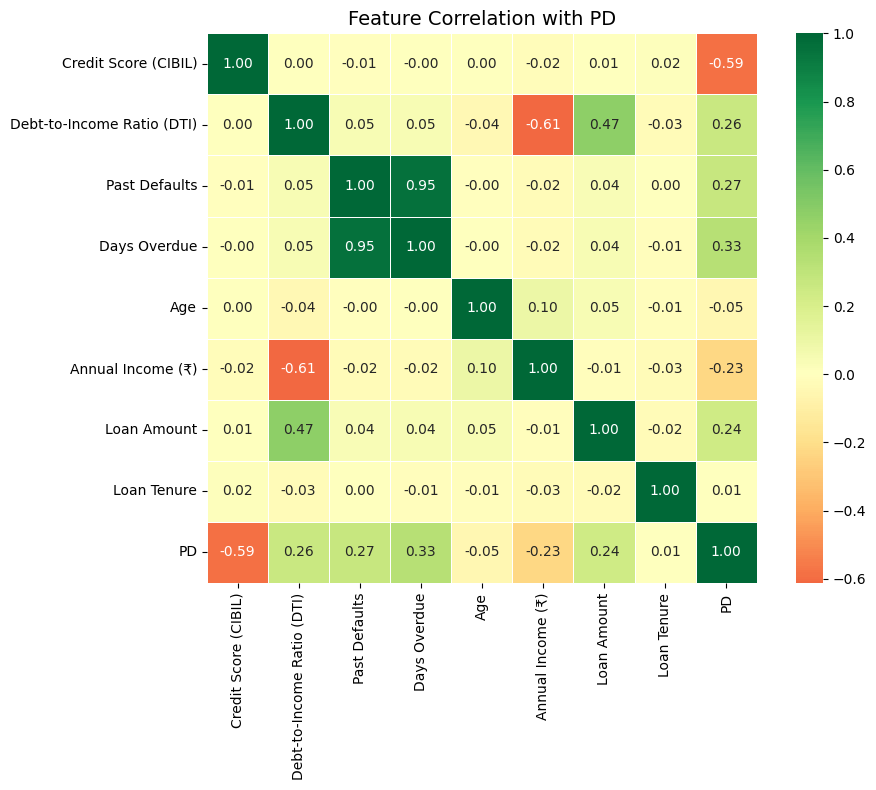

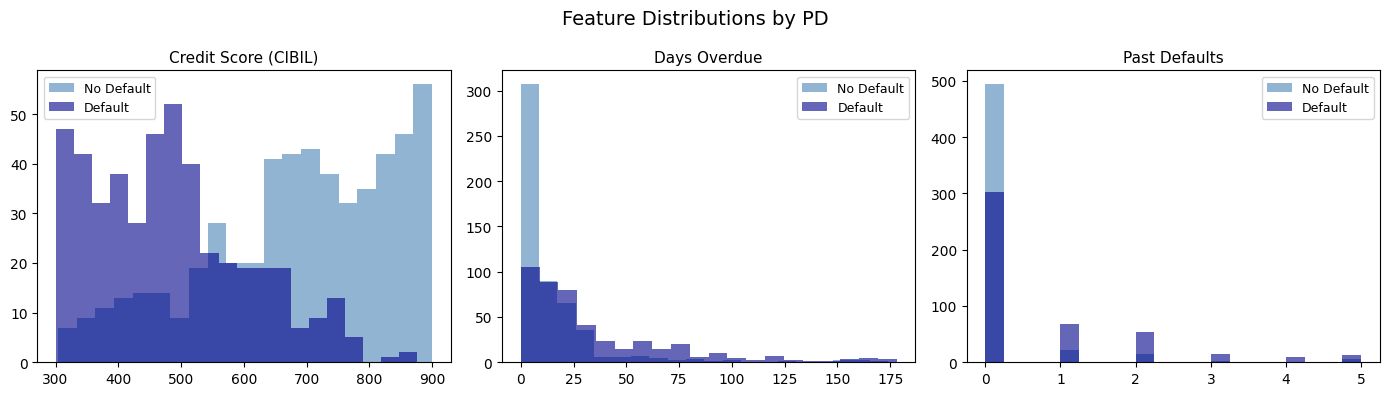

Correlation with PD (Strongest First):
Credit Score (CIBIL)         -0.591800
Annual Income (₹)            -0.227852
Age                          -0.049044
Loan Tenure                   0.006685
Loan Amount                   0.237118
Debt-to-Income Ratio (DTI)    0.259422
Past Defaults                 0.273729
Days Overdue                  0.326593
Name: PD, dtype: float64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
raw_features = [
    'Credit Score (CIBIL)', 'Debt-to-Income Ratio (DTI)',
    'Past Defaults', 'Days Overdue', 'Age', 
    'Annual Income (₹)', 'Loan Amount', 'Loan Tenure', 'PD'
]
plt.figure(figsize=(10,8))
sns.heatmap(df[raw_features].corr(), annot=True,fmt='.2f', cmap='RdYlGn', center=0, linewidth=0.5, square=True
)
plt.title('Feature Correlation with PD', fontsize=14)
plt.tight_layout()
plt.show()
fig,axes = plt.subplots(1, 3, figsize=(14, 4))
no_def = df[df['PD'] == 0]
default = df[df['PD'] == 1]
for ax,col in zip(axes, ['Credit Score (CIBIL)', 'Days Overdue', 'Past Defaults']):
    ax.hist(no_def[col], bins=20, alpha=0.6, label='No Default', color='steelblue')
    ax.hist(default[col], bins=20, alpha=0.6, label='Default', color='darkblue')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=9)
    plt.suptitle('Feature Distributions by PD', fontsize=14)
plt.tight_layout()
plt.show()

print("Correlation with PD (Strongest First):")
print(df[raw_features].corr()['PD'].drop('PD').sort_values())


In [18]:
df['employment_encoded'] = (df['Employment Type'] == 'Salaried').astype(int)
repayment_map = {
    'PAID': 0,
    'DELAYED': 1,
    '1 MONTH DELAYED': 2,
    '2 MONTHS DELAYED': 3,
    '3 MONTHS DELAYED': 4,
    '4 MONTHS DELAYED': 5,
    '5 MONTHS DELAYED': 6,
}
df['repayment_encoded'] = df['Repayment History'].map(repayment_map).fillna(1)
df['product_count'] = (
    df['Product 1'].notna().astype(int) +
    df['Product 2'].notna().astype(int) +
    df['Product 3'].notna().astype(int)
)
df['emi_to_income'] = df['Total EMI / Month (₹)'] / (df['Annual Income (₹)'] / 12)
df['loan_to_income'] = df['Loan Amount'] / df['Annual Income (₹)']

feature_cols = [
    'Credit Score (CIBIL)',
    'Debt-to-Income Ratio (DTI)',
    'Past Defaults',
    'Days Overdue',
    'Age',
    'Annual Income (₹)',
    'Loan Amount',
    'Loan Tenure',
    'Total EMI / Month (₹)',
    'employment_encoded',
    'repayment_encoded',
    'product_count',
    'emi_to_income',
    'loan_to_income'
]
X = df[feature_cols].copy()
Y = df['PD'].copy()

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape : {Y.shape}")
print(f"Nulls in X : {X.isnull().sum().sum()}")
print("\nFeatures used:")
for i, f in enumerate(feature_cols, 1):
    print(f"{i:02d}. {f}")


Feature matrix shape : (1000, 14)
Target vector shape : (1000,)
Nulls in X : 0

Features used:
01. Credit Score (CIBIL)
02. Debt-to-Income Ratio (DTI)
03. Past Defaults
04. Days Overdue
05. Age
06. Annual Income (₹)
07. Loan Amount
08. Loan Tenure
09. Total EMI / Month (₹)
10. employment_encoded
11. repayment_encoded
12. product_count
13. emi_to_income
14. loan_to_income


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)
print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set : {X_test.shape[0]} rows")
print(f"Train PD rate : {Y_train.mean() :.2%}")
print(f"Test PD rate : {Y_test.mean() :.2%}")
print("\nBoth PD rates should be around 46% - confirm stratifiction worked")

Training set : 700 rows
Test set : 300 rows
Train PD rate : 46.14%
Test PD rate : 46.00%

Both PD rates should be around 46% - confirm stratifiction worked


LogisticRegression AUC-ROC : 0.9685

              precision    recall  f1-score   support

  No Default       0.91      0.91      0.91       162
     Default       0.89      0.89      0.89       138

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300


Feature Coefficients (positive = increases PD risk)
                   Feature  Coefficient
      Credit Score (CIBIL)    -3.231353
             Past Defaults    -1.257055
         Annual Income (₹)    -1.158943
             emi_to_income    -0.424015
                       Age    -0.151486
        employment_encoded     0.102360
             product_count     0.140278
               Loan Tenure     0.169697
     Total EMI / Month (₹)     0.348489
            loan_to_income     0.421963
Debt-to-Income Ratio (DTI)     0.421963
         repayment_encoded     0.700986
               Loan Amount     0.885053
              Days Over

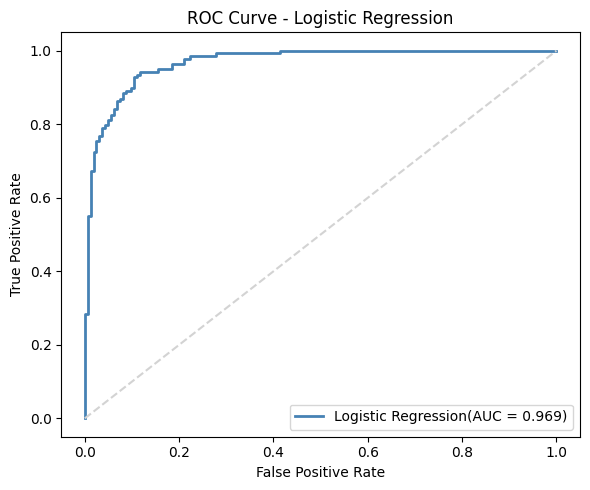

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
lr_model = LogisticRegression(random_state=42, max_iter=500, C=1.0)
lr_model.fit(X_train_scaled, Y_train)
lr_probs = lr_model.predict_proba(X_test_scaled)[: ,1]
lr_auc = roc_auc_score(Y_test, lr_probs)
print(f"LogisticRegression AUC-ROC : {lr_auc:.4f}")
print()
print(classification_report(Y_test, lr_model.predict(X_test_scaled),
                            target_names=['No Default', 'Default']))
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]  
}).sort_values('Coefficient')
print("\nFeature Coefficients (positive = increases PD risk)")
print(coef_df.to_string(index=False))
fpr_lr, tpr_lr, _ = roc_curve(Y_test, lr_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
         label=f'Logistic Regression(AUC = {lr_auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='lightgray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

XGBoost AUC-ROC : 0.9924
Logistic AUC-ROC : 0.9685
Improvement : +0.0239

              precision    recall  f1-score   support

  No Default       0.98      0.98      0.98       162
     Default       0.98      0.98      0.98       138

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



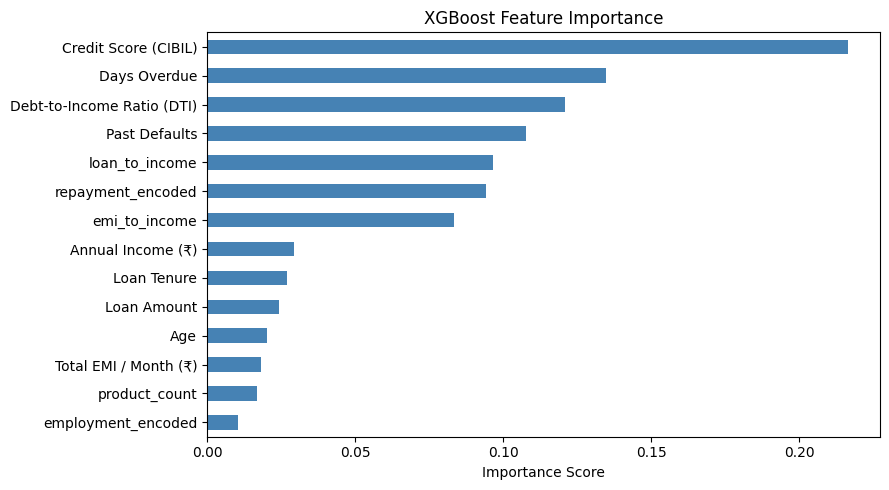

In [21]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)
xgb_model.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=False
)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(Y_test, xgb_probs)
print(f"XGBoost AUC-ROC : {xgb_auc:.4f}")
print(f"Logistic AUC-ROC : {lr_auc:.4f}")
print(f"Improvement : +{(xgb_auc - lr_auc):.4f}")
print()
print(classification_report(Y_test, xgb_model.predict(X_test),
                            target_names=['No Default', 'Default']))
feat_imp = pd.Series(xgb_model.feature_importances_, index =feature_cols)
feat_imp.sort_values().plot(
    kind='barh', figsize=(9, 5),
    title='XGBoost Feature Importance',
    
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
auc= roc_auc_score(Y_test, xgb_probs)
gini = 2 *auc - 1
fpr, tpr, thresholds == roc_curve(Y_test, xgb_probs)
ks_stat = np.max(tpr - fpr)
print("=" * 40)
print("  CREDIT RISK MODEL SCORECARD")
print(f" AUC_ROC : {auc:.4f} target > 0.75")
print(f" Gini : {gini:.4f} target > 0.50")
print(f" KS Stat : {ks_stast:.4f} target > 0.30")
print("=" * 40)
checks = {
    'AUC-ROC > 0.75' : auc > 0.75,
    'Gini > 0.50' : gini > 0.50,
    'KS > 0.30' : ks_stat > 0.30
}

for check, passed in checks.items() :
    status = "PASS" if passed else "FAIL - Needs Tuning"
    print(f" {check} : {status}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(
    xgb_model, X_test, Y_test,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix - XGBoost')
fpr_lr2, tpr_lr2, _ + roc_curve(Y_test, lr_probs)
axes[1].plot(fpr_lpr2, tpr_lr2, color='steelblue' , lw=2,
             label=f'Logistic Regression (AUC={lr_auc:.3f})')
axes[1].plot(fpr, tpr, color='crimson', lw=2,
             label=f'XGBoost (AUC={auc:.3f})')
axes[1].fill-between(fpr, tpr, alpha=0.08, color='crimson')
axes[1].plot([0, 1], [0, 1], '--', color='lightgray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparision')
axes[1].legend()
plt.tight_layout()
plt,show()


NameError: name 'fpr' is not defined